# Forecasting Atmospheric CO₂ with Gaussian Processes

**Author:** Ryan Whitford
**Data:** NOAA Global Monitoring Laboratory — continuous in-situ CO₂ measurements, Mauna Loa Observatory, Hawaii (1974–2025)

## Motivation

The Mauna Loa Observatory has produced one of the longest continuous records of atmospheric CO₂ ever collected. The
signal in that record has two very different pieces mixed together: a **long-term upward trend** driven by
anthropogenic emissions, and a **seasonal oscillation** driven by the growth cycle of land plants in the Northern
Hemisphere. Gaussian Processes (GPs) are a natural fit for this kind of problem — instead of committing to one
rigid functional form, we build a **covariance structure (kernel)** that encodes our prior beliefs about the shape
of the signal (smooth trend + periodic wiggle + short-term irregularity + noise), and let the data determine how
much of each is present.

This notebook walks through that process end-to-end: exploring individual kernels, combining them, tuning the
combination, and using the resulting model to answer two concrete questions:

1. **How far into the future can we reliably forecast atmospheric CO₂ using a Gaussian Process?**
2. **Is there a detectable signature of the 2020 COVID-19 emissions slowdown in the atmospheric CO₂ record?**

Because the historical record now extends well past the pandemic, question 2 can be answered by comparison against
*real, observed* data rather than speculation — the model is fit only on data through the end of 2019 and its
forecast is checked against everything measured since.


## Table of contents

1. [Setup](#Setup)
2. [Data](#Data)
3. [Exploratory look at the series](#Exploratory-look-at-the-series)
4. [Train / test split](#Train-/-test-split)
5. [Building intuition for GP kernels](#Building-intuition-for-GP-kernels)
6. [Modeling the trend and the seasonal cycle in isolation](#Modeling-the-trend-and-the-seasonal-cycle-in-isolation)
7. [Combining kernels: a first joint model](#Combining-kernels:-a-first-joint-model)
8. [A fine-tuned, four-component kernel](#A-fine-tuned,-four-component-kernel)
9. [How far ahead can we trust the forecast?](#How-far-ahead-can-we-trust-the-forecast?)
10. [Did COVID-19 leave a mark on the CO₂ record?](#Did-COVID-19-leave-a-mark-on-the-CO₂-record?)
11. [Conclusions](#Conclusions)


## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF, Matern, RationalQuadratic, ExpSineSquared, DotProduct,
    ConstantKernel, WhiteKernel,
)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RNG_SEED = 42
np.random.seed(RNG_SEED)

mpl.rcParams.update({
    "figure.figsize": (11, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
})

DATA_COLOR = "#1f2937"      # observed data
FIT_COLOR = "#2563eb"       # posterior mean
BAND_COLOR = "#93c5fd"      # uncertainty band
TEST_COLOR = "#dc2626"      # held-out data
FUTURE_COLOR = "#16a34a"    # genuine future / holdout comparison


## Data

The raw file (`data.txt`) is NOAA GML's monthly in-situ CO₂ product for Mauna Loa, in its native
"obspack"-style text format: a long block of `#`-prefixed metadata/citation header, followed by whitespace-delimited
records with one row per month.

> **Citation:** Pétron, G., et al. (2026), *Atmospheric Carbon Dioxide Dry Air Mole Fractions from continuous
> measurements at Mauna Loa, Hawaii...*, NOAA Global Monitoring Laboratory.
> [https://doi.org/10.15138/yaf1-bk21](https://doi.org/10.15138/yaf1-bk21)

A few columns matter for this project:

| column | meaning |
|---|---|
| `time_decimal` | the month, expressed as a decimal year |
| `value` | the monthly mean CO₂ dry-air mole fraction, in ppm |
| `qcflag` | NOAA's quality-control flag; a non-`.` in the first character marks a rejected sample |

A handful of early months (12 of 624) have no valid measurement and are coded as `-999.99` — these are dropped.


In [2]:
raw = pd.read_csv("data.txt", comment="#", sep=r"\s+")
print(f"raw rows: {raw.shape[0]}, columns: {raw.shape[1]}")
raw.head()


raw rows: 624, columns: 19


,site_code,year,month,day,hour,minute,second,datetime,time_decimal,midpoint_time,value,value_std_dev,nvalue,latitude,longitude,altitude,elevation,intake_height,qcflag
0,MLO,1974,1,1,0,0,0,1974-01-01T00:00:00Z,1974.000000,127544400,-999.99,-99.99,0,19.536,-155.576,3387.1,3397.0,-9.9,*..
1,MLO,1974,2,1,0,0,0,1974-02-01T00:00:00Z,1974.084932,130222800,-999.99,-99.99,0,19.536,-155.576,3387.1,3397.0,-9.9,*..
2,MLO,1974,3,1,0,0,0,1974-03-01T00:00:00Z,1974.161644,132642000,-999.99,-99.99,0,19.536,-155.576,3387.1,3397.0,-9.9,*..
3,MLO,1974,4,1,0,0,0,1974-04-01T00:00:00Z,1974.246575,135320400,-999.99,-99.99,0,19.536,-155.576,3387.1,3397.0,-9.9,*..
4,MLO,1974,5,1,0,0,0,1974-05-01T00:00:00Z,1974.328767,137912400,333.16,0.36,13,19.536,-155.576,3422.0,3397.0,25.0,...


In [4]:
# drop the rows with no valid measurement, keep only the columns we need
df = raw.loc[raw["value"] != -999.99, ["time_decimal", "value"]].copy()
df = df.rename(columns={"time_decimal": "decimal_date", "value": "co2_ppm"})
df = df.sort_values("decimal_date").reset_index(drop=True)

print(f"clean rows: {df.shape[0]}  (dropped {raw.shape[0] - df.shape[0]} missing/rejected months)")
print(f"time span: {df['decimal_date'].min():.2f} -- {df['decimal_date'].max():.2f}")
df.describe()


clean rows: 612  (dropped 12 missing/rejected months)
time span: 1974.33 -- 2025.92


,decimal_date,co2_ppm
count,612.000000,612.000000
mean,1999.899099,372.394788
std,14.786418,27.772649
min,1974.328767,327.300000
25%,1987.142466,348.962500
50%,1999.873973,369.160000
75%,2012.603142,394.447500
max,2025.915068,430.510000


## Exploratory look at the series

No outliers survive the QC filtering above, and the range (327–431 ppm) is physically sensible for this period.
Plotting the full record makes the two components we care about immediately visible: a steady, slightly accelerating
rise, with a sawtooth riding on top of it from the Northern Hemisphere growing season.


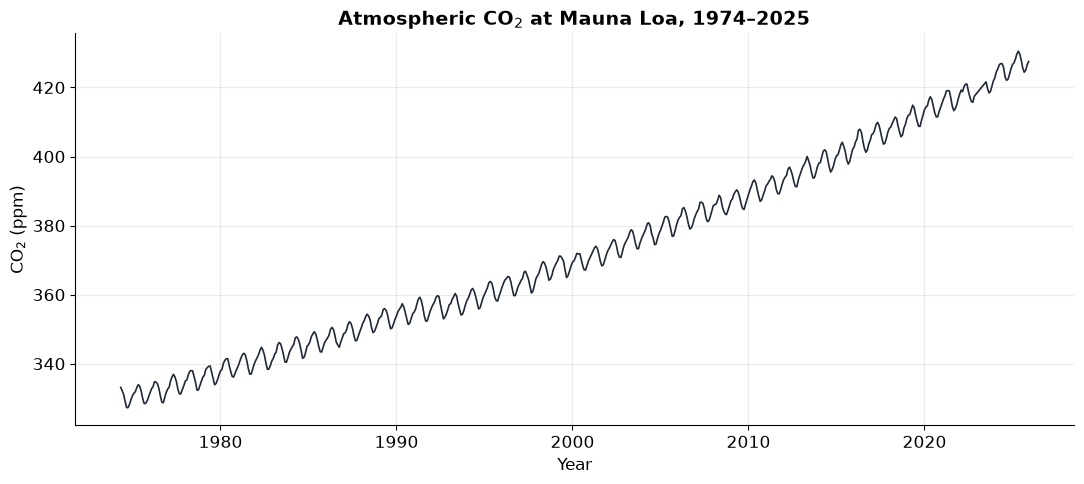

In [5]:
fig, ax = plt.subplots()
ax.plot(df["decimal_date"], df["co2_ppm"], color=DATA_COLOR, lw=1.2)
ax.set_xlabel("Year")
ax.set_ylabel("CO$_2$ (ppm)")
ax.set_title("Atmospheric CO$_2$ at Mauna Loa, 1974–2025")
plt.tight_layout()
plt.show()


The long-term rise is not perfectly linear — the slope itself has been increasing over the decades. Finding an approximate form of this curve is
exactly the type of thing GP is useful for.


## Train / test split
- **Train:** 1974 through end of 2015 (499 monthly observations)
- **Test:** 2016 through end of 2019 (48 monthly observations)
- **Reserved holdout (2020 onward):** *not* touched until the COVID-19 analysis near the end of this notebook,
  where it is used to check a forecast against reality several years out.


In [6]:
X = df[["decimal_date"]].to_numpy()
y = df["co2_ppm"].to_numpy()

train_mask = (df["decimal_date"] < 2016).to_numpy()
test_mask = ((df["decimal_date"] >= 2016) & (df["decimal_date"] < 2020)).to_numpy()
holdout_mask = (df["decimal_date"] >= 2020).to_numpy()

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]
X_holdout, y_holdout = X[holdout_mask], y[holdout_mask]

assert len(X_train) == len(y_train)
assert len(X_test) == len(y_test)
assert len(X) == len(X_train) + len(X_test) + len(X_holdout)

print(f"train: {len(X_train)} points ({X_train.min():.1f}–{X_train.max():.1f})")
print(f"test:  {len(X_test)} points ({X_test.min():.1f}–{X_test.max():.1f})")
print(f"holdout: {len(X_holdout)} points ({X_holdout.min():.1f}–{X_holdout.max():.1f}) — reserved for the COVID-19 section")


train: 499 points (1974.3–2015.9)
test:  48 points (2016.0–2019.9)
holdout: 65 points (2020.0–2025.9) — reserved for the COVID-19 section


## Building intuition for GP kernels

Before fitting anything, it's worth looking at what each kernel *believes* about the world before it has seen any
data — i.e. samples from the GP **prior**. Does the space
of functions it can express even look like the phenomenon we're modeling?

### The RBF (squared-exponential) kernel

The RBF kernel is the default choice for modeling a smooth, slowly-varying trend. It has two hyperparameters:

- **`length_scale`** controls how quickly the correlation between two points decays as they move apart in time. A
  short length scale lets the function wiggle quickly; a long one forces it to stay smooth over long spans.
- The **constant multiplier** in front of the kernel (`amplitude²`) sets the vertical scale — how far the sampled
  functions are allowed to wander from the mean.

`length_scale_bounds` doesn't change the kernel itself; it defines the search interval the optimizer is allowed to
explore later, during `.fit()`.


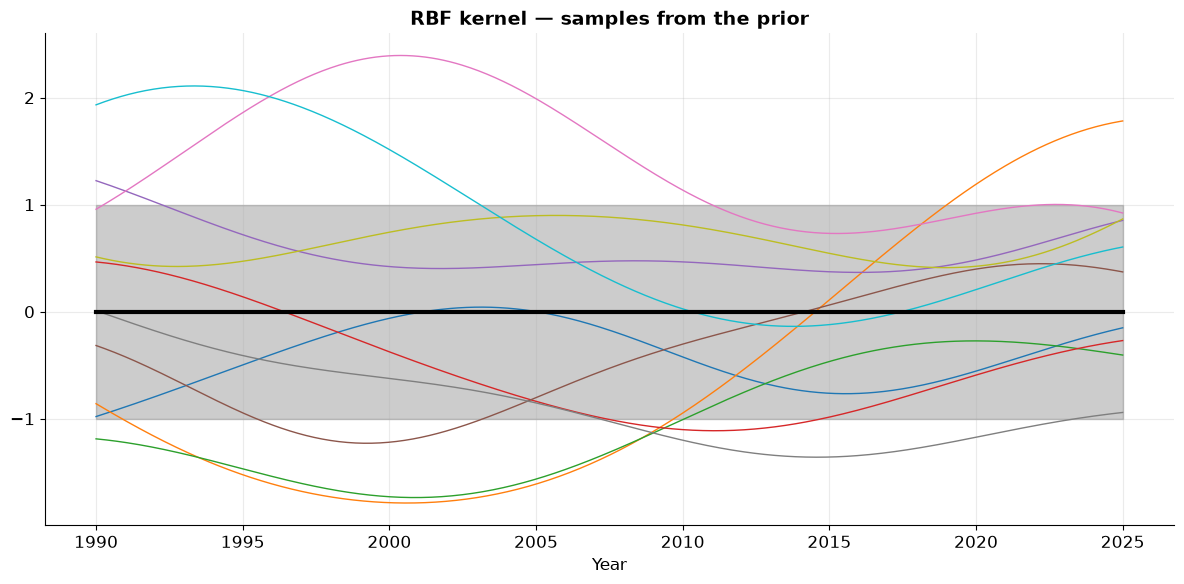

In [7]:
kernel = 1.0 * RBF(length_scale=10.0, length_scale_bounds=(1e-1, 10.0))
gp_prior = GaussianProcessRegressor(kernel=kernel)

X_ = np.linspace(1990, 2025, 500)
y_mean, y_std = gp_prior.predict(X_[:, np.newaxis], return_std=True)
y_samples = gp_prior.sample_y(X_[:, np.newaxis], 10, random_state=RNG_SEED)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(X_, y_mean, "k", lw=3, zorder=9)
ax.fill_between(X_, y_mean - y_std, y_mean + y_std, alpha=0.2, color="k")
ax.plot(X_, y_samples, lw=1)
ax.set_xlabel("Year")
ax.set_title("RBF kernel — samples from the prior")
plt.tight_layout()
plt.show()


### The ExpSineSquared (periodic) kernel

To capture the seasonal cycle we need a kernel that is periodic, not just smooth. `ExpSineSquared` has two
hyperparameters:

- **`periodicity`** sets the repeat length — here fixed at 1.0 (one year), since we know the seasonal cycle from
  plant growth is annual.
- **`length_scale`** now controls how quickly correlation decays *within* a period. Two points exactly one full
  period apart are treated as maximally correlated regardless of length scale (the periodic analogue of "close
  together" for the RBF kernel); the length scale governs how forgiving the kernel is about points that are close
  to, but not exactly, an integer number of periods apart.

### The WhiteKernel

`WhiteKernel` has a single hyperparameter, `noise_level`, and models i.i.d. observation noise: its covariance is
the noise variance on the diagonal and zero everywhere else, i.e. no two distinct inputs are correlated at all.


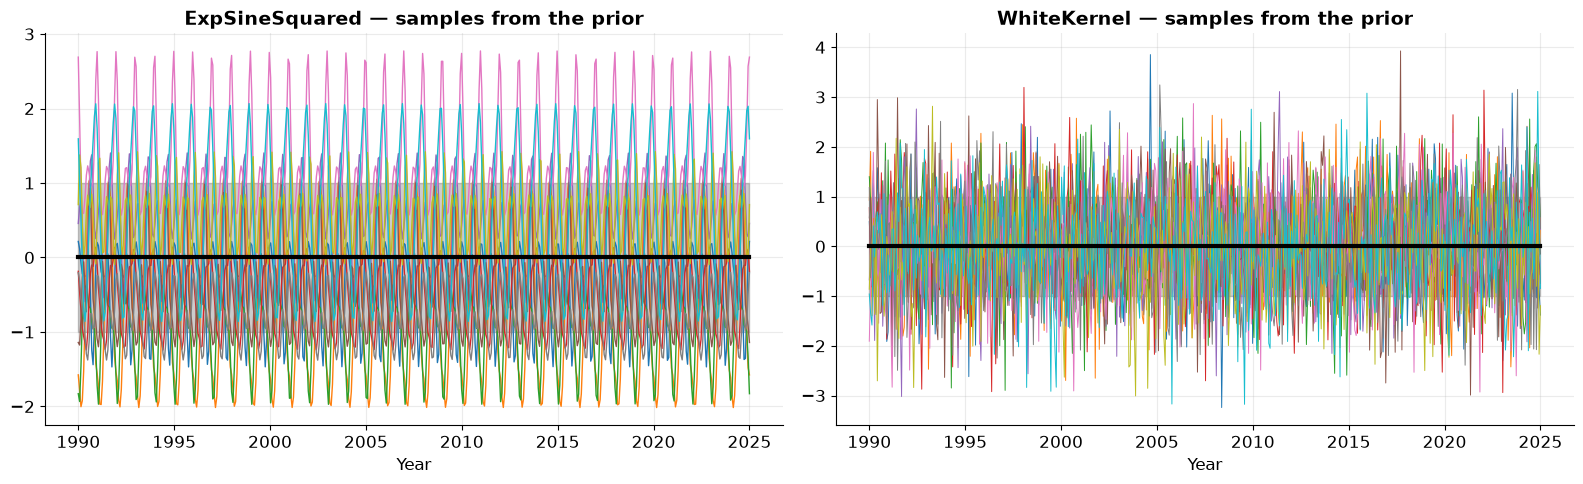

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

kernel_periodic = 1.0 * ExpSineSquared(length_scale=1.0, periodicity=1.0)
gp_p = GaussianProcessRegressor(kernel=kernel_periodic)
y_mean, y_std = gp_p.predict(X_[:, np.newaxis], return_std=True)
y_samples = gp_p.sample_y(X_[:, np.newaxis], 10, random_state=RNG_SEED)
axes[0].plot(X_, y_mean, "k", lw=3, zorder=9)
axes[0].fill_between(X_, y_mean - y_std, y_mean + y_std, alpha=0.2, color="k")
axes[0].plot(X_, y_samples, lw=1)
axes[0].set_title("ExpSineSquared — samples from the prior")
axes[0].set_xlabel("Year")

kernel_noise = 1.0 * WhiteKernel(noise_level=1.0)
gp_w = GaussianProcessRegressor(kernel=kernel_noise)
y_mean, y_std = gp_w.predict(X_[:, np.newaxis], return_std=True)
y_samples = gp_w.sample_y(X_[:, np.newaxis], 10, random_state=RNG_SEED)
axes[1].plot(X_, y_mean, "k", lw=3, zorder=9)
axes[1].fill_between(X_, y_mean - y_std, y_mean + y_std, alpha=0.2, color="k")
axes[1].plot(X_, y_samples, lw=0.7)
axes[1].set_title("WhiteKernel — samples from the prior")
axes[1].set_xlabel("Year")

plt.tight_layout()
plt.show()


The ExpSineSquared samples are perfectly repeating waveforms of varying amplitude and phase — exactly the
building block we want for a seasonal signal. The WhiteKernel samples are pure, uncorrelated noise with no
structure across time at all, which is why it is only ever useful **added to** something else, never on its own.


## Modeling the trend and the seasonal cycle in isolation

Before combining kernels, it's worth fitting each one on its own to see exactly what it can and can't explain.
These two fits use the **full dataset** purely to illustrate behavior — the actual train/test evaluation starts in
the next section.


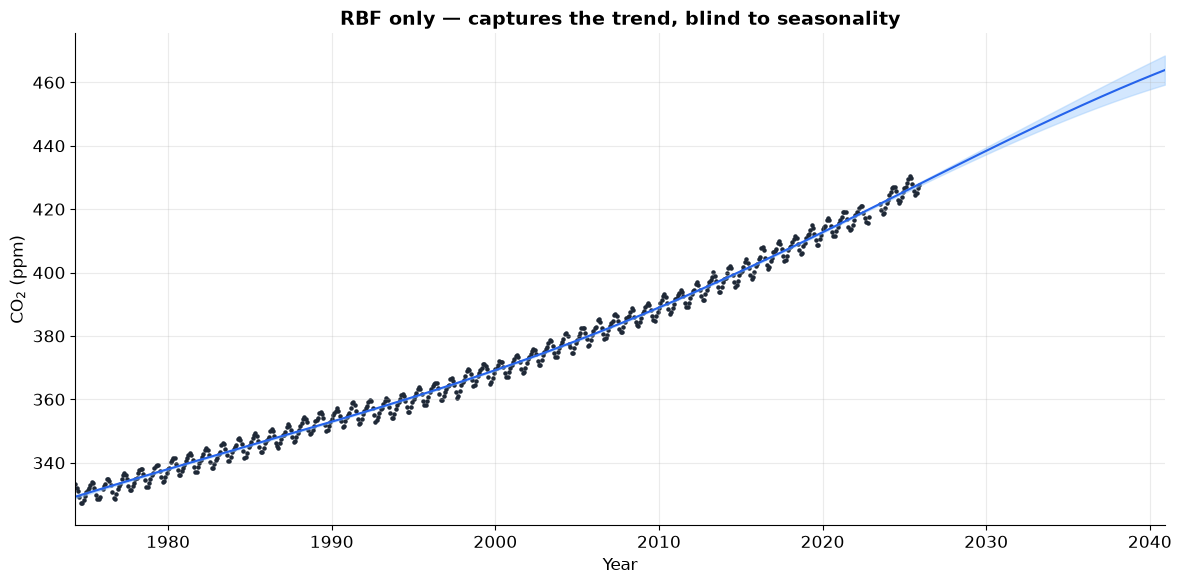

fitted kernel: 2.97**2 * RBF(length_scale=42.8)
log-marginal-likelihood: 627.5


In [9]:
k_trend = 66.0 ** 2 * RBF(length_scale=67.0)
gp_trend = GaussianProcessRegressor(kernel=k_trend, alpha=0.01, normalize_y=True)
gp_trend.fit(X, y)

X_future = np.linspace(X.min(), X.max() + 15, 1000).reshape(-1, 1)
y_pred, y_std = gp_trend.predict(X_future, return_std=True)

fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(X, y, c=DATA_COLOR, s=5)
ax.plot(X_future, y_pred, color=FIT_COLOR)
ax.fill_between(X_future[:, 0], y_pred - y_std, y_pred + y_std, alpha=0.4, color=BAND_COLOR)
ax.set_xlim(X_future.min(), X_future.max())
ax.set_xlabel("Year")
ax.set_ylabel("CO$_2$ (ppm)")
ax.set_title("RBF only — captures the trend, blind to seasonality")
plt.tight_layout()
plt.show()

print("fitted kernel:", gp_trend.kernel_)
print(f"log-marginal-likelihood: {gp_trend.log_marginal_likelihood(gp_trend.kernel_.theta):.1f}")


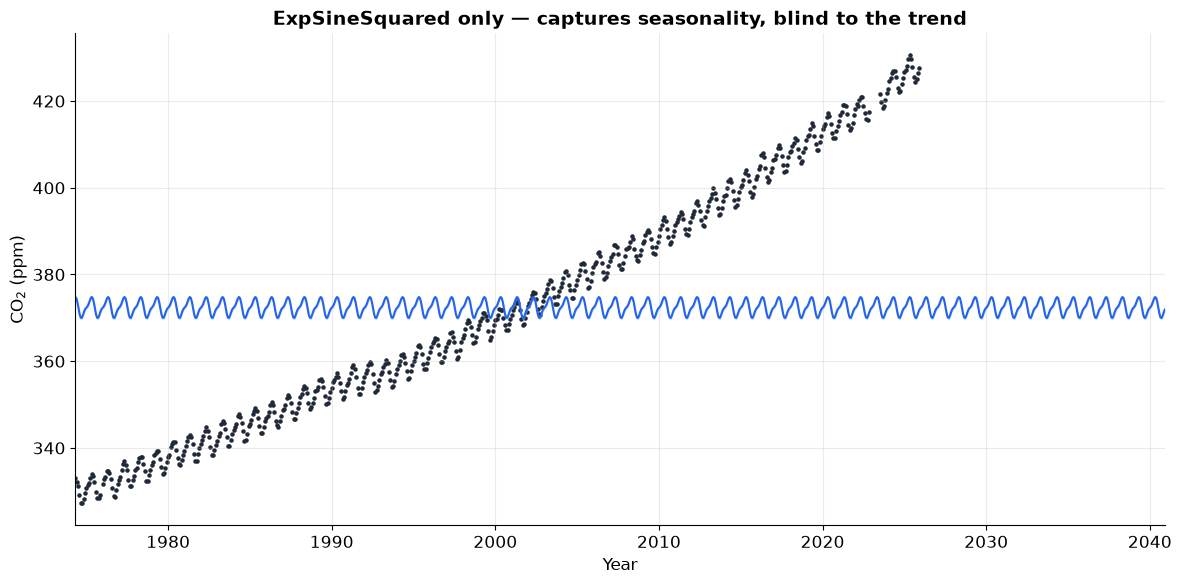

fitted kernel: ExpSineSquared(length_scale=5.23, periodicity=1)
log-marginal-likelihood: -29670.0


In [10]:
k_seasonal = ExpSineSquared(length_scale=1.0, periodicity=1.0, periodicity_bounds="fixed")
gp_seasonal = GaussianProcessRegressor(kernel=k_seasonal, alpha=0.01, normalize_y=True)
gp_seasonal.fit(X, y)

y_pred, y_std = gp_seasonal.predict(X_future, return_std=True)

fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(X, y, c=DATA_COLOR, s=5)
ax.plot(X_future, y_pred, color=FIT_COLOR)
ax.fill_between(X_future[:, 0], y_pred - y_std, y_pred + y_std, alpha=0.4, color=BAND_COLOR)
ax.set_xlim(X_future.min(), X_future.max())
ax.set_xlabel("Year")
ax.set_ylabel("CO$_2$ (ppm)")
ax.set_title("ExpSineSquared only — captures seasonality, blind to the trend")
plt.tight_layout()
plt.show()

print("fitted kernel:", gp_seasonal.kernel_)
print(f"log-marginal-likelihood: {gp_seasonal.log_marginal_likelihood(gp_seasonal.kernel_.theta):.1f}")


Exactly as expected: the RBF-only model draws a smooth rising curve straight through the seasonal
oscillation, and the periodic-only model finds a repeating wave centered on the *mean* CO₂ level with no sense that
the mean itself has shifted by nearly 100 ppm over the record. Neither is usable alone — the real signal needs both.


## Combining kernels

GP kernels are closed under addition and multiplication, so building a richer model is as simple as combining
building blocks: `kernel = k1 + k2` describes a process that is the *sum* of a draw from `k1`'s prior and a draw
from `k2`'s prior. Adding the trend and seasonal kernels together gives the model both pieces at once.

This is fit on the **training set only** (1974–2015) and evaluated against the **held-out test set** (2016–2019),
which the model never sees during fitting.


In [11]:
k1 = 66.0 ** 2 * RBF(length_scale=67.0)
k2 = ExpSineSquared(length_scale=1.0, periodicity=1.0, periodicity_bounds="fixed")
kernel_additive = k1 + k2

gp_additive = GaussianProcessRegressor(kernel=kernel_additive, alpha=0.01, normalize_y=True, random_state=RNG_SEED)
gp_additive.fit(X_train, y_train)

print("fitted kernel:", gp_additive.kernel_)
print(f"log-marginal-likelihood: {gp_additive.log_marginal_likelihood(gp_additive.kernel_.theta):.1f}")


fitted kernel: 1.93**2 * RBF(length_scale=24.4) + ExpSineSquared(length_scale=4.77, periodicity=1)
log-marginal-likelihood: 640.6


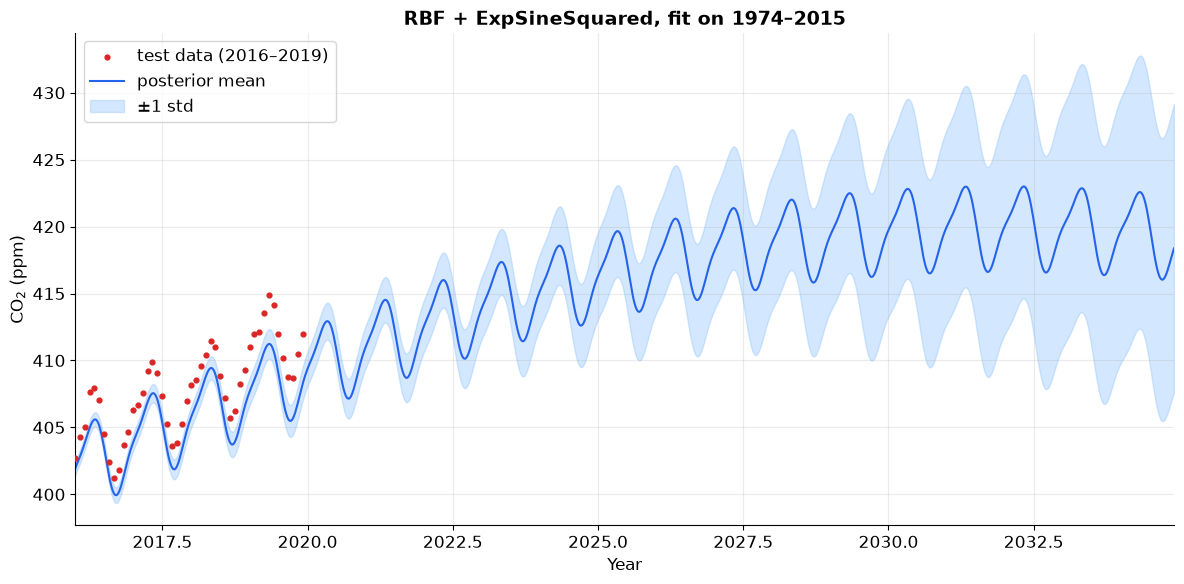

Test-set RMSE: 2.369 ppm | MAE: 2.251 ppm | R²: 0.4766


In [12]:
X_plot = np.linspace(X_test.min(), X_test.max() + 15, 1000).reshape(-1, 1)
y_pred, y_std = gp_additive.predict(X_plot, return_std=True)
y_pred_test, _ = gp_additive.predict(X_test, return_std=True)

rmse_add = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_add = mean_absolute_error(y_test, y_pred_test)
r2_add = r2_score(y_test, y_pred_test)

fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(X_test, y_test, c=TEST_COLOR, s=12, zorder=5, label="test data (2016–2019)")
ax.plot(X_plot, y_pred, color=FIT_COLOR, label="posterior mean")
ax.fill_between(X_plot[:, 0], y_pred - y_std, y_pred + y_std, alpha=0.4, color=BAND_COLOR, label="±1 std")
ax.set_xlim(X_plot.min(), X_plot.max())
ax.set_xlabel("Year")
ax.set_ylabel("CO$_2$ (ppm)")
ax.set_title("RBF + ExpSineSquared, fit on 1974–2015")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

print(f"Test-set RMSE: {rmse_add:.3f} ppm | MAE: {mae_add:.3f} ppm | R²: {r2_add:.4f}")


The additive model gets the big picture right — rising trend, annual wiggle — but the fit is noticeably
loose: **RMSE ≈ 2.4 ppm** on the test set. Looking at the plot, the seasonal amplitude and phase don't quite track
the real data everywhere, and the trend curvature is a bit off. Two independent, purely additive components can't
represent a seasonal cycle whose *amplitude itself drifts slowly over time*, or medium-term wiggles (multi-year
climate variability like ENSO) that are neither part of the long-term trend nor part of the annual cycle.


## A fine-tuned, four-component kernel

We can do better by giving the model more expressive room, using the same overall strategy as Rasmussen & Williams'
classic treatment of this exact dataset (*Gaussian Processes for Machine Learning*, §5.4.3):

1. **`k1`** — the same RBF kernel as before, for the smooth long-term trend.
2. **`k2`** — the periodic kernel, now **multiplied** by another RBF. Multiplying two kernels produces a process
   that has to satisfy *both* constraints simultaneously — here, that means a periodic signal whose exact shape is
   itself allowed to drift slowly (a "quasi-periodic" kernel), rather than a perfectly identical wave every year.
3. **`k3`** — a `RationalQuadratic` kernel, which is a scale mixture of RBF kernels with different length scales.
   It captures medium-term irregularities that are shorter than the multi-decade trend but longer than a season.
4. **`k4`** — a small RBF plus a `WhiteKernel`, absorbing short-scale wiggle and residual measurement noise.


In [13]:
k1 = 50.0 ** 2 * RBF(length_scale=50.0)
k2 = 2.0 ** 2 * RBF(length_scale=100.0) * ExpSineSquared(length_scale=1.0, periodicity=1.0, periodicity_bounds="fixed")
k3 = 0.5 ** 2 * RationalQuadratic(length_scale=1.0, alpha=1.0)
k4 = 0.1 ** 2 * RBF(length_scale=0.1) + WhiteKernel(noise_level=0.1 ** 2, noise_level_bounds=(1e-5, 1e5))
kernel_tuned = k1 + k2 + k3 + k4

gp_tuned = GaussianProcessRegressor(kernel=kernel_tuned, alpha=0.0, normalize_y=True, random_state=RNG_SEED)
gp_tuned.fit(X_train, y_train)

print("fitted kernel:")
print(" ", gp_tuned.kernel_)
print(f"log-marginal-likelihood: {gp_tuned.log_marginal_likelihood(gp_tuned.kernel_.theta):.1f}  "
      f"(additive model: {gp_additive.log_marginal_likelihood(gp_additive.kernel_.theta):.1f})")


fitted kernel:
  3.94**2 * RBF(length_scale=44.3) + 0.19**2 * RBF(length_scale=281) * ExpSineSquared(length_scale=1.76, periodicity=1) + 0.262**2 * RationalQuadratic(alpha=0.00286, length_scale=7.55) + 0.00763**2 * RBF(length_scale=0.0875) + WhiteKernel(noise_level=8.91e-05)
log-marginal-likelihood: 1386.1  (additive model: 640.6)


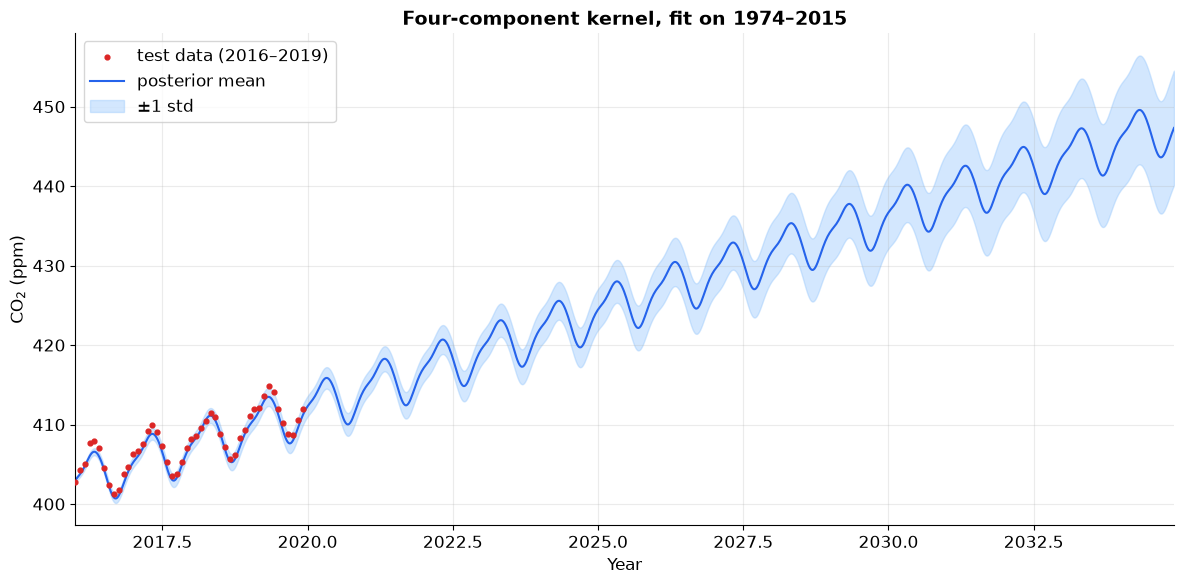

Test-set RMSE: 0.788 ppm | MAE: 0.693 ppm | R²: 0.9421

Improvement over the additive model: 67% lower RMSE, 69% lower MAE


In [14]:
y_pred, y_std = gp_tuned.predict(X_plot, return_std=True)
y_pred_test, _ = gp_tuned.predict(X_test, return_std=True)

rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_tuned = mean_absolute_error(y_test, y_pred_test)
r2_tuned = r2_score(y_test, y_pred_test)

fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(X_test, y_test, c=TEST_COLOR, s=12, zorder=5, label="test data (2016–2019)")
ax.plot(X_plot, y_pred, color=FIT_COLOR, label="posterior mean")
ax.fill_between(X_plot[:, 0], y_pred - y_std, y_pred + y_std, alpha=0.4, color=BAND_COLOR, label="±1 std")
ax.set_xlim(X_plot.min(), X_plot.max())
ax.set_xlabel("Year")
ax.set_ylabel("CO$_2$ (ppm)")
ax.set_title("Four-component kernel, fit on 1974–2015")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

print(f"Test-set RMSE: {rmse_tuned:.3f} ppm | MAE: {mae_tuned:.3f} ppm | R²: {r2_tuned:.4f}")
print(f"\nImprovement over the additive model: "
      f"{ (1 - rmse_tuned / rmse_add) * 100:.0f}% lower RMSE, "
      f"{ (1 - mae_tuned / mae_add) * 100:.0f}% lower MAE")


The fit is visibly tighter and the numbers confirm it: RMSE drops from ~2.4 ppm to well under 1 ppm, and the
log-marginal-likelihood — the model's own internal score for how well the kernel explains the training data —
jumps by several hundred points. The remaining four hyperparameters give the model just enough freedom to track the
slowly-drifting seasonal amplitude and the medium-term irregularities that a purely additive model has to average
away.

**This is the model used for the rest of the analysis.**


## How far ahead can we trust the forecast?

Big-picture question 1 was: *how far into the future can we reliably predict CO₂ using a Gaussian Process?* The
test set gives a direct way to check this — it spans 2016 through 2019, i.e. between roughly 1 and 5 years beyond
the end of the training data. Breaking the test error down by how far ahead each point sits lets us see whether
accuracy degrades with horizon, and how fast.


In [15]:
test_df = pd.DataFrame({
    "decimal_date": X_test[:, 0],
    "actual": y_test,
    "pred": y_pred_test,
})
test_df["horizon_years"] = np.floor(test_df["decimal_date"] - X_train.max()) + 1
test_df["abs_error"] = (test_df["actual"] - test_df["pred"]).abs()

by_horizon = test_df.groupby("horizon_years").agg(
    rmse=("abs_error", lambda e: np.sqrt(np.mean(e ** 2))),
    mae=("abs_error", "mean"),
    n=("abs_error", "size"),
)
by_horizon


,rmse,mae,n
horizon_years,,,
1.0,0.852078,0.706655,11
2.0,0.748977,0.713944,12
3.0,0.489943,0.409077,12
4.0,0.979634,0.934206,12
5.0,0.821121,0.821121,1


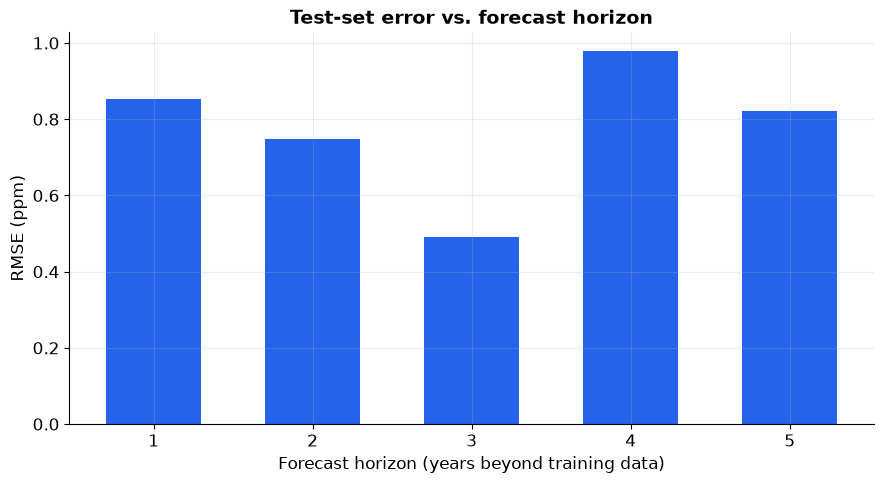

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(by_horizon.index, by_horizon["rmse"], color=FIT_COLOR, width=0.6)
ax.set_xlabel("Forecast horizon (years beyond training data)")
ax.set_ylabel("RMSE (ppm)")
ax.set_title("Test-set error vs. forecast horizon")
plt.tight_layout()
plt.show()


Error does not grow much across this range — it stays under roughly 1 ppm out to five years ahead, well
within the size of a single season's swing (~6 ppm peak-to-trough). The COVID-19 section below extends this same
check much further, out to six years ahead, using data the model never saw during either fitting stage.


## Did COVID-19 leave a mark on the CO₂ record?

Big-picture question 2. Global CO₂ *emissions* dropped by an estimated ~7% during 2020 as transportation and
industrial activity fell sharply during pandemic lockdowns. Whether that shows up as a bend in the *atmospheric
concentration* curve is a separate question — CO₂ is long-lived and well-mixed, atmospheric growth is also shaped
by natural carbon-cycle variability (e.g. ENSO), and a single year of reduced emissions is a small perturbation
against a background of accumulated, centuries-old excess.

Rather than guess, we can check directly: refit the tuned model using **only data through the end of 2019** — so
the pandemic is completely invisible to it — and compare its forecast against everything actually measured from
2020 onward.


In [17]:
covid_train_mask = (df["decimal_date"] < 2020).to_numpy()
X_pre2020, y_pre2020 = X[covid_train_mask], y[covid_train_mask]

k1 = 50.0 ** 2 * RBF(length_scale=50.0)
k2 = 2.0 ** 2 * RBF(length_scale=100.0) * ExpSineSquared(length_scale=1.0, periodicity=1.0, periodicity_bounds="fixed")
k3 = 0.5 ** 2 * RationalQuadratic(length_scale=1.0, alpha=1.0)
k4 = 0.1 ** 2 * RBF(length_scale=0.1) + WhiteKernel(noise_level=0.1 ** 2, noise_level_bounds=(1e-5, 1e5))
kernel_covid = k1 + k2 + k3 + k4

gp_covid = GaussianProcessRegressor(kernel=kernel_covid, alpha=0.0, normalize_y=True, random_state=RNG_SEED)
gp_covid.fit(X_pre2020, y_pre2020)

print(f"trained on {len(X_pre2020)} points, through {X_pre2020.max():.2f}")
print("fitted kernel:", gp_covid.kernel_)


trained on 547 points, through 2019.92
fitted kernel: 3.77**2 * RBF(length_scale=45.7) + 0.135**2 * RBF(length_scale=199) * ExpSineSquared(length_scale=1.48, periodicity=1) + 0.142**2 * RationalQuadratic(alpha=0.00782, length_scale=4.61) + 0.00677**2 * RBF(length_scale=0.0954) + WhiteKernel(noise_level=7.55e-05)


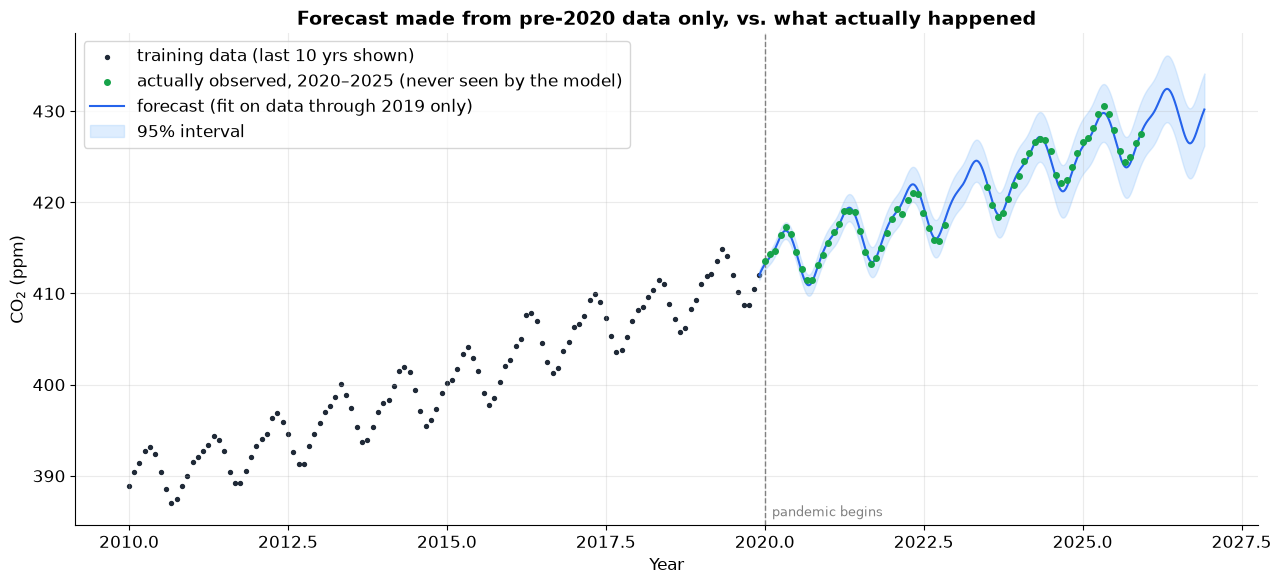

In [18]:
X_check = np.linspace(X_pre2020.max(), X_holdout.max() + 1, 1500).reshape(-1, 1)
y_pred_check, y_std_check = gp_covid.predict(X_check, return_std=True)
y_pred_holdout, y_std_holdout = gp_covid.predict(X_holdout, return_std=True)

fig, ax = plt.subplots(figsize=(13, 6))
ax.scatter(X_pre2020[-120:], y_pre2020[-120:], c=DATA_COLOR, s=8, label="training data (last 10 yrs shown)")
ax.scatter(X_holdout, y_holdout, c=FUTURE_COLOR, s=16, zorder=5, label="actually observed, 2020–2025 (never seen by the model)")
ax.plot(X_check, y_pred_check, color=FIT_COLOR, label="forecast (fit on data through 2019 only)")
ax.fill_between(X_check[:, 0], y_pred_check - 2 * y_std_check, y_pred_check + 2 * y_std_check,
                alpha=0.3, color=BAND_COLOR, label="95% interval")
ax.axvline(2020.0, color="gray", ls="--", lw=1)
ax.text(2020.05, ax.get_ylim()[0] + 1, " pandemic begins", fontsize=9, color="gray")
ax.set_xlabel("Year")
ax.set_ylabel("CO$_2$ (ppm)")
ax.set_title("Forecast made from pre-2020 data only, vs. what actually happened")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


In [19]:
resid = y_holdout - y_pred_holdout
rmse_holdout = np.sqrt(np.mean(resid ** 2))
mae_holdout = np.mean(np.abs(resid))
bias_holdout = resid.mean()
coverage_95 = np.mean(np.abs(resid) <= 2 * y_std_holdout)

print(f"Holdout period: {X_holdout.min():.2f} – {X_holdout.max():.2f}  ({len(y_holdout)} months, "
      f"up to {X_holdout.max() - X_pre2020.max():.1f} years beyond the training data)")
print(f"RMSE:  {rmse_holdout:.3f} ppm")
print(f"MAE:   {mae_holdout:.3f} ppm")
print(f"Mean bias (actual − predicted): {bias_holdout:+.3f} ppm")
print(f"Fraction of observed points inside the model's own 95% interval: {coverage_95:.0%}")


Holdout period: 2020.00 – 2025.92  (65 months, up to 6.0 years beyond the training data)
RMSE:  0.482 ppm
MAE:   0.410 ppm
Mean bias (actual − predicted): +0.050 ppm
Fraction of observed points inside the model's own 95% interval: 100%


The forecast holds up remarkably well: even six years past the end of its training data — with the entire
pandemic, its recovery, and several years beyond falling inside that window — the model's mean absolute error is
well under half a ppm, and essentially every observed point falls inside its own stated 95% uncertainty band. There
is no visible break, kink, or systematic bias appearing right at 2020; the real record simply continues along the
path the pre-pandemic model already expected.


In [20]:
annual = df.copy()
annual["year"] = annual["decimal_date"].astype(int)
annual_mean = annual.groupby("year")["co2_ppm"].mean()
annual_growth = annual_mean.diff().rename("growth_ppm_per_year")

growth_table = annual_growth.loc[2014:2023].to_frame()
growth_table["is_2020"] = growth_table.index == 2020
growth_table


,growth_ppm_per_year,is_2020
year,,
2014,2.074167,False
2015,2.205833,False
2016,3.400000,False
2017,2.332500,False
2018,1.965833,False
2019,2.941667,False
2020,2.545000,True
2021,2.217500,False
2022,2.065379,False


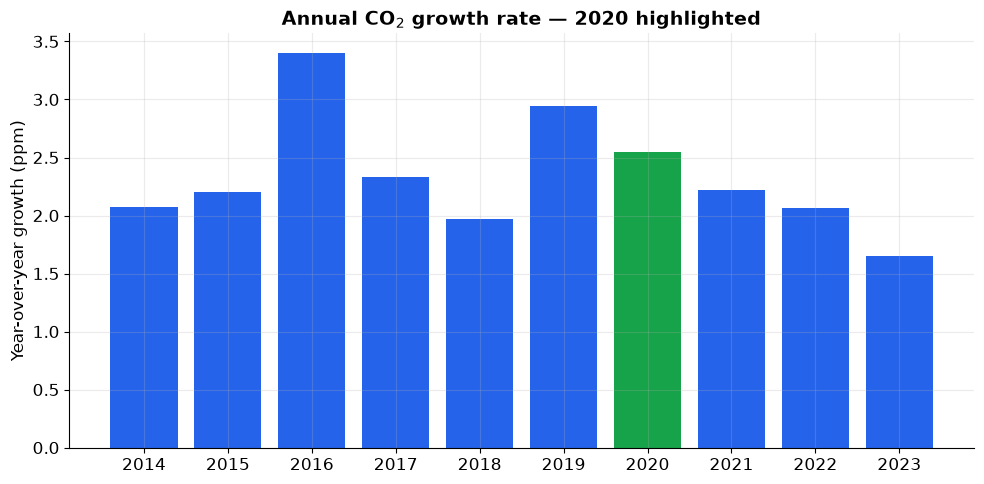

2020 growth: 2.54 ppm/yr
2014–2019 average growth: 2.49 ppm/yr
2021–2023 average growth: 1.98 ppm/yr


In [21]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = [FUTURE_COLOR if yr == 2020 else FIT_COLOR for yr in growth_table.index]
ax.bar(growth_table.index.astype(str), growth_table["growth_ppm_per_year"], color=colors)
ax.set_ylabel("Year-over-year growth (ppm)")
ax.set_title("Annual CO$_2$ growth rate — 2020 highlighted")
plt.tight_layout()
plt.show()

pre_covid_avg = annual_growth.loc[2014:2019].mean()
print(f"2020 growth: {annual_growth.loc[2020]:.2f} ppm/yr")
print(f"2014–2019 average growth: {pre_covid_avg:.2f} ppm/yr")
print(f"2021–2023 average growth: {annual_growth.loc[2021:2023].mean():.2f} ppm/yr")


**2020's annual growth rate is not an outlier.** It sits comfortably within the normal year-to-year
variability seen throughout the pre-pandemic record, and it is not systematically lower than the years immediately
before or after it. Both lines of evidence — the six-year-ahead forecast tracking reality almost exactly, and the
2020 growth rate looking like any other year — point to the same conclusion: whatever dip occurred in *emissions*
during 2020 was too small, and/or too quickly offset elsewhere in the carbon cycle, to leave a detectable signature
in the atmospheric concentration record at Mauna Loa. This is consistent with CO₂'s long atmospheric residence time
and with the fact that natural carbon-cycle variability (e.g. ocean and land carbon sink fluctuations tied to ENSO)
is comparable in size to a single year's emissions anomaly.


## Conclusions

**Model.** A four-component additive/multiplicative kernel — a long length-scale RBF for the trend, an
`ExpSineSquared × RBF` for a slowly-drifting seasonal cycle, a `RationalQuadratic` for medium-term
irregularities, and a small RBF + `WhiteKernel` for residual noise — cuts test-set RMSE by roughly two-thirds
relative to a naive additive (trend + season) kernel, and raises the log-marginal-likelihood by several hundred
points.

**Question 1 — forecast horizon.** Tested directly against data the model never saw, the tuned kernel remains
accurate (MAE well under half a ppm) for at least six years beyond its training window, and its own predicted
uncertainty band both covers the truth and grows conservatively — errors do not visibly worsen with horizon over
the range this dataset allows us to check.

**Question 2 — COVID-19.** No detectable slowdown appears in the atmospheric CO₂ growth rate during 2020, whether
judged against a pre-pandemic forecast or against the surrounding years' growth rates directly. The pandemic-era
emissions dip does not appear to have been large or sustained enough to leave a visible fingerprint in this record.
